In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math
import pickle
from collections import Counter
import sys
import os

In [2]:
sys.path.append(os.path.abspath(".."))

from lago_data_model.model_utils import eval_predictions, compare_models, save_model

In [3]:
import random

RANDOM_STATE = 42
TEST_SIZE = 0.3

# Reproducibilidad: numpy + python (TF se siembra después de importarse)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## Load Data

In [4]:
with open("all_segments.pkl", "rb") as f:
    segments = pickle.load(f)

### Construir matriz de señal

Entrada al modelo: la **señal cruda del pulso** recortada alrededor del mínimo, normalizada por segmento y re-muestreada a una longitud fija (`SIGNAL_LEN`). Empezamos con un modelo "normal" para validar el flujo; el ajuste FPGA-friendly (vía hls4ml: `SIGNAL_LEN` menor, capas más chicas, cuantización) se hace después.

In [ ]:
from lago_data_model.data_utils import segments_to_matrix, signal_to_vector


In [ ]:
# Parámetros del pre-procesamiento de señal (los persistimos al guardar el modelo)
SIGNAL_LEN = 128
N_BEFORE   = 40
N_AFTER    = 87       # n_before + n_after + 1 = SIGNAL_LEN
SCALE      = "robust"

X_sig = segments_to_matrix(
    segments,
    n_before=N_BEFORE, n_after=N_AFTER,
    resample_len=SIGNAL_LEN,
    normalize=True, scale=SCALE,
)
print("X_sig:", X_sig.shape, X_sig.dtype)


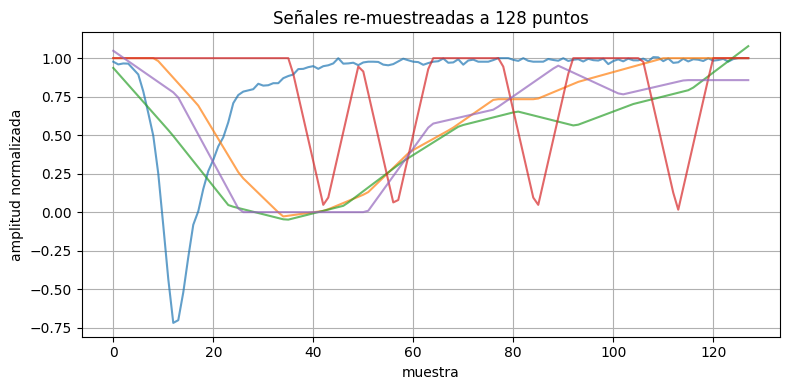

In [7]:
# sanity check: 5 pulsos aleatorios de la matriz
rng = np.random.default_rng(0)
idx = rng.choice(len(X_sig), size=min(5, len(X_sig)), replace=False)
plt.figure(figsize=(8,4))
for k in idx:
    plt.plot(X_sig[k], alpha=0.7)
plt.title(f"Señales re-muestreadas a {SIGNAL_LEN} puntos")
plt.xlabel("muestra"); plt.ylabel("amplitud normalizada")
plt.grid(True); plt.tight_layout(); plt.show()


### Load k-means Labels

In [8]:
with open('kmeans_labels.pkl', 'rb') as handle:
    labels = pickle.load(handle)

Distribución de clases:
  clase 0:    82303  ( 3.00%)
  clase 1:  1209377  (44.09%)
  clase 2:   111097  ( 4.05%)
  clase 3:  1335355  (48.68%)
  clase 4:     4749  ( 0.17%)
  total:    2742881

ratio max/min: 281.2  → desbalance significativo


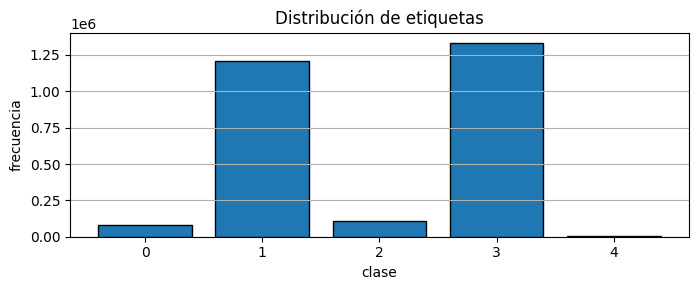

In [9]:
# Distribución de clases
unique, counts = np.unique(labels, return_counts=True)
total = counts.sum()
print("Distribución de clases:")
for c, n in zip(unique, counts):
    print(f"  clase {c}: {n:>8d}  ({100*n/total:5.2f}%)")
print(f"  total:    {total}")

# Ratio max/min: si > ~5 conviene usar class_weight
ratio = counts.max() / counts.min()
print(f"\nratio max/min: {ratio:.1f}  → {'desbalance significativo' if ratio > 5 else 'balance razonable'}")

plt.figure(figsize=(7,3))
plt.bar(unique, counts, edgecolor="black")
plt.xlabel("clase"); plt.ylabel("frecuencia"); plt.title("Distribución de etiquetas")
plt.grid(True, axis="y"); plt.tight_layout(); plt.show()


# Modelo MLP

#### Dividir dataset

In [10]:
from sklearn.model_selection import train_test_split

assert len(X_sig) == len(labels), "X_sig y labels deben estar alineados por índice"

X_trval, X_te, y_trval, y_te = train_test_split(
    X_sig, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trval, y_trval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trval
)

num_classes = len(np.unique(labels))
print("X_tr:", X_tr.shape, "| X_val:", X_val.shape, "| X_te:", X_te.shape, "| num_classes:", num_classes)

# class_weight calculado SOLO con train (evita filtrar info de val/test)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
class_weight_dict = {int(k): float(v) for k, v in zip(np.unique(y_tr), cw)}
print("class_weight:", class_weight_dict)


X_tr: (1440012, 128) | X_val: (480004, 128) | X_te: (822865, 128) | num_classes: 5
class_weight: {0: 6.665333611053253, 1: 0.4536020903322135, 2: 4.9378047525974695, 3: 0.4108093304291638, 4: 115.52442839951865}


## MLP 

In [11]:
import numpy as np
import hls4ml
print("NumPy:", np.__version__)
print("hls4ml:", hls4ml.__version__)

NumPy: 1.26.4
hls4ml: 1.3.0


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses
import matplotlib.pyplot as plt

2026-05-10 05:25:59.166369: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 05:25:59.178295: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-10 05:25:59.193592: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-10 05:25:59.197602: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 05:25:59.207387: I tensorflow/core/platform/cpu_feature_guar

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [13]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs visibles: {len(gpus)} → usando TensorFlow con GPU")
    except Exception as e:
        print("No se pudo configurar memory growth:", e)
else:
    print("No se detectó GPU: se entrenará en CPU")

# Reproducibilidad para TF (cubre tf, np y python en una sola llamada)
tf.keras.utils.set_random_seed(RANDOM_STATE)


GPUs visibles: 1 → usando TensorFlow con GPU


In [14]:
def build_mlp(in_dim: int, hidden_size1: int, hidden_size2: int, out_dim: int) -> keras.Model:
    return keras.Sequential([
        layers.Input(shape=(in_dim,)),
        layers.Dense(hidden_size1, activation='relu'),
        layers.Dense(hidden_size2, activation='relu'),
        layers.Dense(out_dim)  # sin activación: logits
    ], name="MLP")

In [15]:
class PrintLRChange(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        opt = self.model.optimizer
        lr = float(tf.keras.backend.get_value(opt.learning_rate))
        # Cuando ReduceLROnPlateau ajusta el LR, Keras ya imprime (verbose=1). Este callback asegura el log cada época.
        print(f"[Epoch {epoch+1:03d}] current_lr = {lr:.6f}")

In [16]:
import os
from datetime import datetime

def train_model_tf(model: keras.Model,
                   Xtr, ytr, Xte, yte,
                   epochs: int = 20,
                   bs: int = 64,
                   lr: float = 1e-3,
                   patience: int = 5,
                   lr_patience: int = 5,
                   tb_logdir: str = "logs/MLP",
                   run_name: str | None = None,
                   class_weight: dict | None = None):

    # Datasets (equivalente a DataLoader)
    train_ds = tf.data.Dataset.from_tensor_slices((Xtr, ytr)).shuffle(len(Xtr)).batch(bs).prefetch(tf.data.AUTOTUNE)
    val_ds   = tf.data.Dataset.from_tensor_slices((Xte, yte)).batch(bs).prefetch(tf.data.AUTOTUNE)

    # Optimizador y pérdida (y* deben ser enteros de clase; si tienes one-hot, usa CategoricalCrossentropy)
    opt = optimizers.Adam(learning_rate=lr)
    loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

    # TensorBoard: una carpeta por corrida
    if run_name is None:
        run_name = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = os.path.join(tb_logdir, run_name)
    os.makedirs(run_dir, exist_ok=True)
    print(f"[TensorBoard] logdir: {run_dir}")
    if class_weight is not None:
        print(f"[class_weight] {class_weight}")

    # Callbacks: ReduceLR + EarlyStopping + TensorBoard + log de LR por epoch
    cb = [
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=lr_patience, verbose=1, min_delta=0.0),
        callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1),
        callbacks.TensorBoard(
            log_dir=run_dir,
            histogram_freq=1,        # histogramas de pesos por epoch
            write_graph=True,
            update_freq='epoch',
            profile_batch=0,         # 0 = sin profiler (evita problemas con CUDA en algunos setups)
        ),
        PrintLRChange(),
    ]

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1,
        callbacks=cb,
        class_weight=class_weight,
    )

    # Curvas de aprendizaje: loss + accuracy + lr
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(hist.history['loss'], label='train')
    axes[0].plot(hist.history['val_loss'], label='val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(hist.history['accuracy'], label='train')
    axes[1].plot(hist.history['val_accuracy'], label='val')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
    axes[1].legend(); axes[1].grid(True)

    if 'lr' in hist.history or 'learning_rate' in hist.history:
        lr_key = 'lr' if 'lr' in hist.history else 'learning_rate'
        axes[2].plot(hist.history[lr_key])
        axes[2].set_yscale('log')
        axes[2].set_title('Learning rate'); axes[2].set_xlabel('epoch'); axes[2].set_ylabel('lr (log)')
        axes[2].grid(True)
    else:
        axes[2].axis('off')

    plt.tight_layout(); plt.show()

    return model, hist, run_dir


### TensorBoard

Lanza TensorBoard apuntando a `logs/MLP`. Se actualiza solo a medida que `train_model_tf` escribe métricas y pesos.

Alternativa desde terminal: `tensorboard --logdir notebooks/logs/MLP --port 6006`

In [17]:
%load_ext tensorboard
%tensorboard --logdir logs/MLP --port 6006


In [18]:
model_params = {
    "input_size":   X_tr.shape[1],     # = SIGNAL_LEN
    "hidden_size1": 128,
    "hidden_size2": 32,
    "output_size":  num_classes,
    "epochs": 300,
    "lr": 5e-4,
    "batch_size": 1500,
}


In [19]:
mlp_tf = build_mlp(
    in_dim=model_params["input_size"],
    hidden_size1=model_params["hidden_size1"],
    hidden_size2=model_params["hidden_size2"],
    out_dim=model_params["output_size"]
)

2026-05-10 05:26:06.724443: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13282 MB memory:  -> device: 0, name: NVIDIA A2, pci bus id: 0000:44:00.0, compute capability: 8.6


[TensorBoard] logdir: logs/MLP/20260510-052608
[class_weight] {0: 6.665333611053253, 1: 0.4536020903322135, 2: 4.9378047525974695, 3: 0.4108093304291638, 4: 115.52442839951865}
Epoch 1/300


I0000 00:00:1778390770.555112    1689 service.cc:146] XLA service 0x7f49dc0034f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778390770.555149    1689 service.cc:154]   StreamExecutor device (0): NVIDIA A2, Compute Capability 8.6
2026-05-10 05:26:10.574827: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-10 05:26:10.672010: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
2026-05-10 05:26:11.672137: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_337', 24 bytes spill stores, 24 bytes spill loads

2026-05-10 05:26:11.771102: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion

 66/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4762 - loss: 1.2003

I0000 00:00:1778390772.941859    1689 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6981 - loss: 0.6959[Epoch 001] current_lr = 0.000500
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7519 - loss: 0.5343 - val_accuracy: 0.7614 - val_loss: 0.6680 - learning_rate: 5.0000e-04
Epoch 2/300
948/961 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4045[Epoch 002] current_lr = 0.000500
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7982 - loss: 0.3986 - val_accuracy: 0.7553 - val_loss: 0.6410 - learning_rate: 5.0000e-04
Epoch 3/300
956/961 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8047 - loss: 0.3798[Epoch 003] current_lr = 0.000500
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8080 - loss: 0.3721 - val_accuracy: 0.8074 - val_loss: 0.5272 - learning_rate: 5.0000e-04
Epoch 4/300
952/961 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8077 - loss: 0.3708[Epoch 004] current_lr = 0.000500
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8104 - loss: 0.3616 - val_accuracy: 0.808

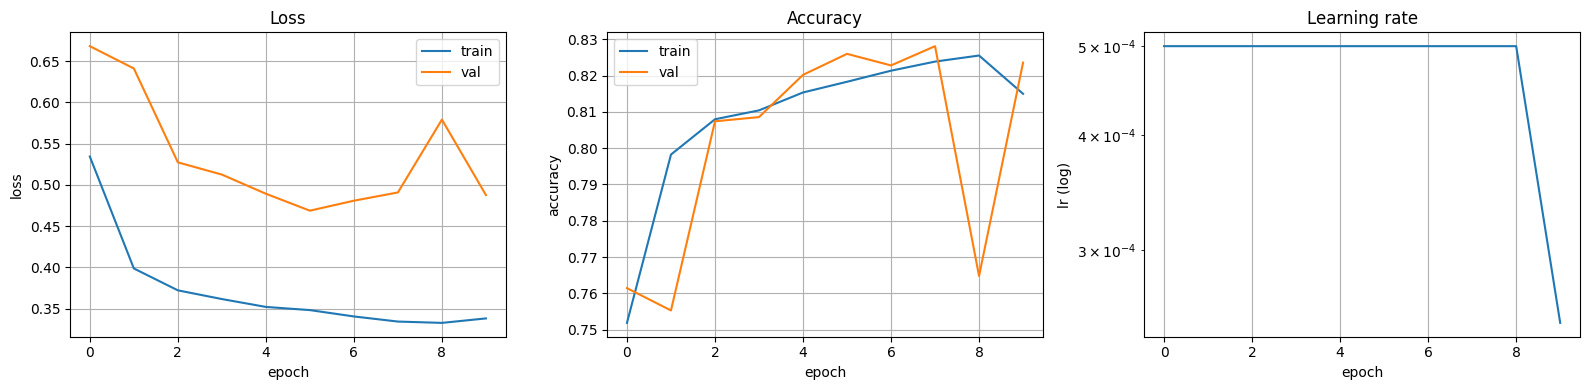

In [20]:
mlp_tf, hist, run_dir = train_model_tf(
    mlp_tf,
    X_tr, y_tr, X_val, y_val,
    epochs=model_params["epochs"],
    bs=model_params["batch_size"],
    lr=model_params["lr"],
    patience=4,
    lr_patience=3,
    tb_logdir="logs/MLP",
    class_weight=class_weight_dict,
)


In [21]:
logits_te = mlp_tf.predict(X_te, batch_size=model_params["batch_size"], verbose=0)
proba_mlp = tf.nn.softmax(logits_te).numpy()
print("proba_mlp:", proba_mlp.shape)


proba_mlp: (822865, 5)


=== Métricas agregadas ===
Macro     -> P: 0.6262 | R: 0.8649 | F1: 0.6863
Weighted  -> P: 0.8409 | R: 0.8255 | F1: 0.8300

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       0.49      0.91      0.64     24691
           1       0.83      0.81      0.82    362813
           2       0.75      0.93      0.83     33329
           3       0.88      0.82      0.85    400607
           4       0.17      0.85      0.29      1425

    accuracy                           0.83    822865
   macro avg       0.63      0.86      0.69    822865
weighted avg       0.84      0.83      0.83    822865



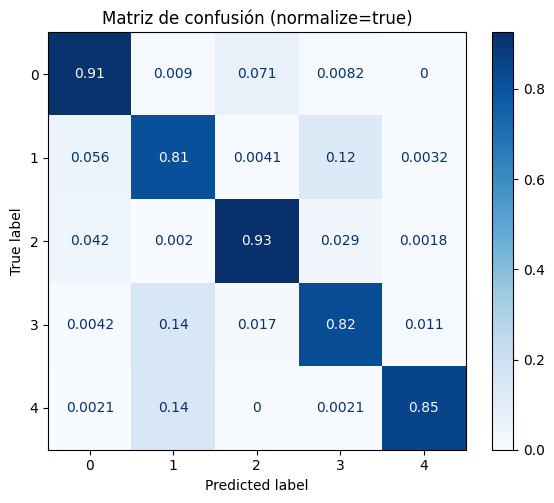


ROC-AUC multiclase:
  micro-average: 0.9700
  macro-average (ovr): 0.9628


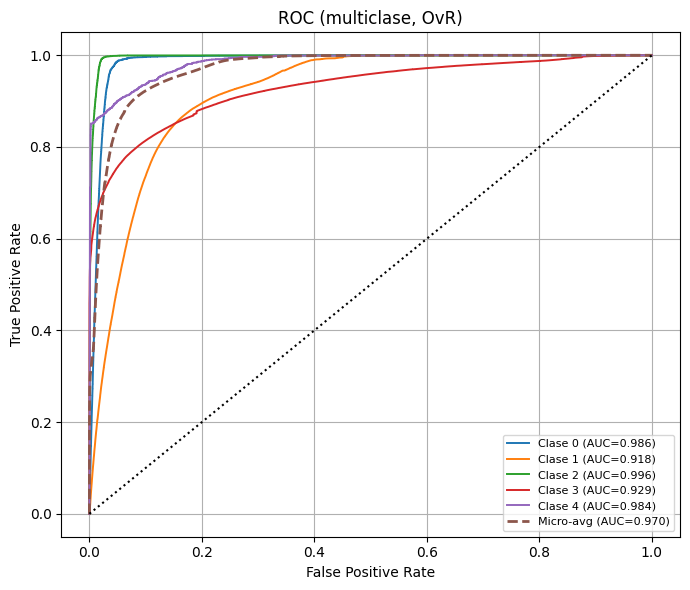


Average Precision multiclase:
  micro-average AP: 0.8904
  clase 0 AP: 0.5713
  clase 1 AP: 0.8669
  clase 2 AP: 0.9156
  clase 3 AP: 0.9415
  clase 4 AP: 0.4588


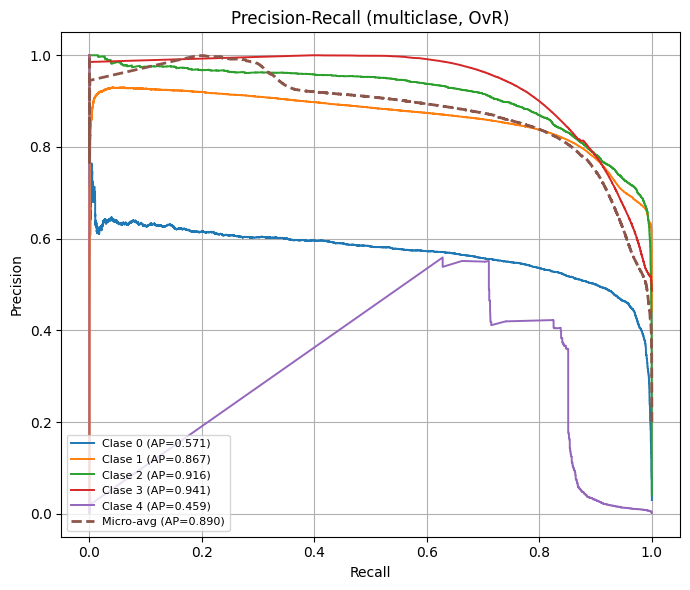

In [22]:
_ = eval_predictions(y_true=y_te, y_pred=proba_mlp, plot_cm=True, plot_roc=True, plot_pr=True)

## Búsqueda Bayesiana de hiperparámetros

Usamos `keras-tuner` con `BayesianOptimization` para explorar el espacio de hiperparámetros (capas ocultas, dropout, learning rate) maximizando `val_accuracy`. Cada trial entrena con `EarlyStopping` para acelerar la búsqueda. Al final re-entrenamos el mejor modelo con `train_model_tf` (TensorBoard incluido) y lo evaluamos en test.

In [23]:
import keras_tuner as kt

def build_mlp_hp(hp):
    in_dim = X_tr.shape[1]
    out_dim = num_classes

    h1 = hp.Int("hidden_size1", min_value=32, max_value=256, step=32)
    h2 = hp.Int("hidden_size2", min_value=8,  max_value=128, step=8)
    dropout = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    model = keras.Sequential([
        layers.Input(shape=(in_dim,)),
        layers.Dense(h1, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(h2, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(out_dim),  # logits
    ], name="MLP_HP")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return model


In [24]:
tuner = kt.BayesianOptimization(
    hypermodel=build_mlp_hp,
    objective=kt.Objective("val_loss", direction="min"),  # val_loss más robusto a desbalance que accuracy
    max_trials=20,
    num_initial_points=5,
    directory="kt_search",
    project_name="MLP_signal",
    overwrite=True,
)

tuner.search_space_summary()


Search space summary
Default search space size: 4
hidden_size1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
hidden_size2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 128, 'step': 8, 'sampling': 'linear'}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [25]:
tuner.search(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,                          # epochs por trial (cortos)
    batch_size=model_params["batch_size"],
    callbacks=[
        callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ],
    verbose=2,
)

tuner.results_summary(num_trials=5)


Trial 20 Complete [00h 02m 30s]
val_loss: 0.23219311237335205

Best val_loss So Far: 0.23009540140628815
Total elapsed time: 00h 38m 31s
Results summary
Results in kt_search/MLP_signal
Showing 5 best trials
Objective(name="val_loss", direction="min")

Trial 16 summary
Hyperparameters:
hidden_size1: 256
hidden_size2: 128
dropout: 0.2
lr: 0.0001
Score: 0.23009540140628815

Trial 19 summary
Hyperparameters:
hidden_size1: 192
hidden_size2: 128
dropout: 0.2
lr: 0.0001
Score: 0.23219311237335205

Trial 08 summary
Hyperparameters:
hidden_size1: 256
hidden_size2: 80
dropout: 0.2
lr: 0.0001
Score: 0.2362380474805832

Trial 01 summary
Hyperparameters:
hidden_size1: 224
hidden_size2: 56
dropout: 0.1
lr: 0.00025680189659437386
Score: 0.23680126667022705

Trial 10 summary
Hyperparameters:
hidden_size1: 160
hidden_size2: 96
dropout: 0.1
lr: 0.0001
Score: 0.24094362556934357


In [26]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Mejores hiperparámetros:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")


Mejores hiperparámetros:
  hidden_size1: 256
  hidden_size2: 128
  dropout: 0.2
  lr: 0.0001


[TensorBoard] logdir: logs/MLP_tuned/20260510-060553
[class_weight] {0: 6.665333611053253, 1: 0.4536020903322135, 2: 4.9378047525974695, 3: 0.4108093304291638, 4: 115.52442839951865}
Epoch 1/300
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6409 - loss: 0.9483[Epoch 001] current_lr = 0.000100
961/961 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6881 - loss: 0.7449 - val_accuracy: 0.7580 - val_loss: 0.6971 - learning_rate: 1.0000e-04
Epoch 2/300
954/961 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7445 - loss: 0.5316[Epoch 002] current_lr = 0.000100
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7480 - loss: 0.5079 - val_accuracy: 0.7688 - val_loss: 0.6047 - learning_rate: 1.0000e-04
Epoch 3/300
954/961 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7605 - loss: 0.4771[Epoch 003] current_lr = 0.000100
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7637 - loss: 0.4716 - val_accuracy: 0.7799 - val_loss: 0.5900 - learning_rate: 1.0000e-04
Epoch 4/300
954/961 ━

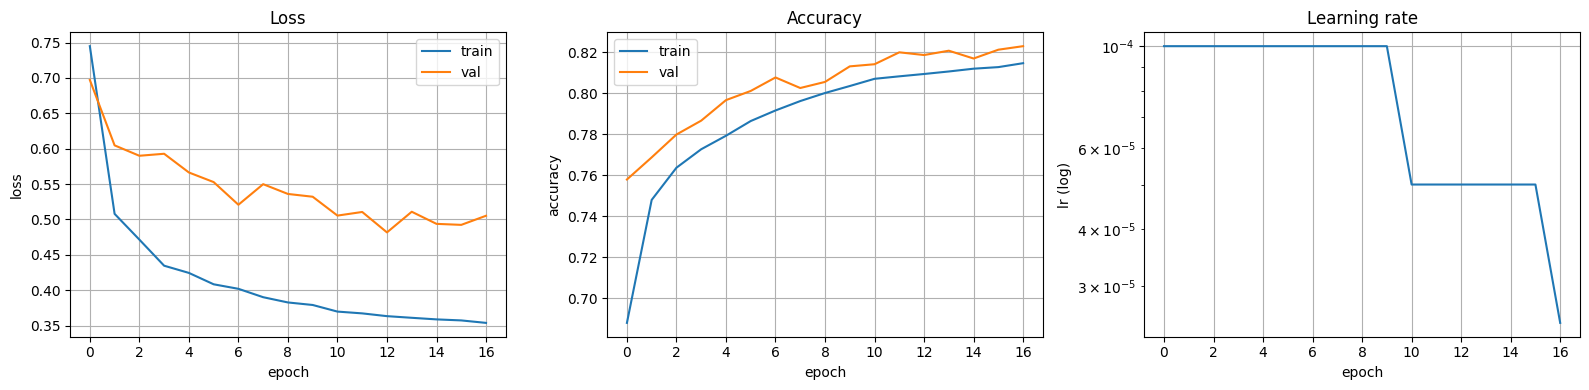

In [27]:
# Re-entrenar el mejor modelo con epochs completos + TensorBoard
mlp_best = tuner.hypermodel.build(best_hp)

mlp_best, hist_best, run_dir_best = train_model_tf(
    mlp_best,
    X_tr, y_tr, X_val, y_val,
    epochs=model_params["epochs"],
    bs=model_params["batch_size"],
    lr=best_hp.get("lr"),
    patience=4,
    lr_patience=3,
    tb_logdir="logs/MLP_tuned",
    class_weight=class_weight_dict,
)


=== Métricas agregadas ===
Macro     -> P: 0.6111 | R: 0.8684 | F1: 0.6737
Weighted  -> P: 0.8428 | R: 0.8183 | F1: 0.8234

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       0.49      0.92      0.64     24691
           1       0.80      0.86      0.83    362813
           2       0.69      0.95      0.80     33329
           3       0.92      0.76      0.83    400607
           4       0.16      0.85      0.27      1425

    accuracy                           0.82    822865
   macro avg       0.61      0.87      0.67    822865
weighted avg       0.84      0.82      0.82    822865



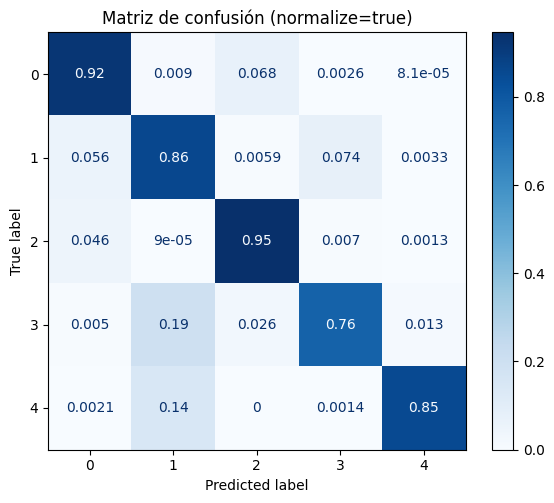


ROC-AUC multiclase:
  micro-average: 0.9682
  macro-average (ovr): 0.9615


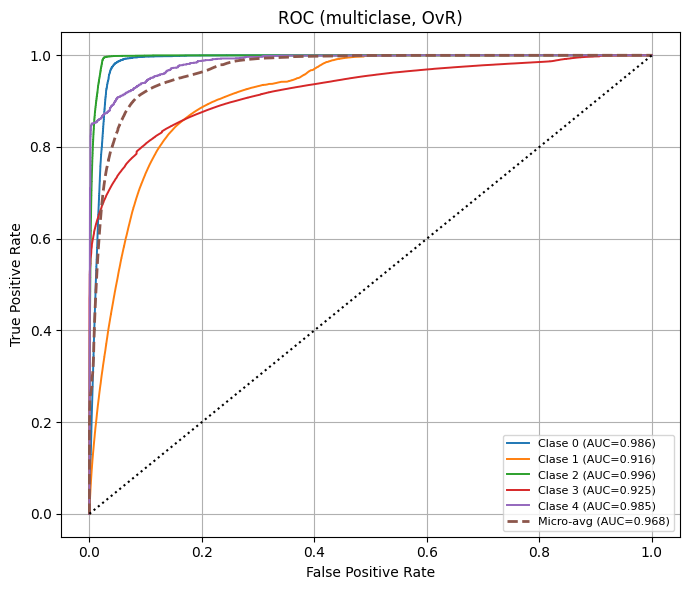


Average Precision multiclase:
  micro-average AP: 0.8852
  clase 0 AP: 0.5648
  clase 1 AP: 0.8727
  clase 2 AP: 0.9014
  clase 3 AP: 0.9379
  clase 4 AP: 0.4740


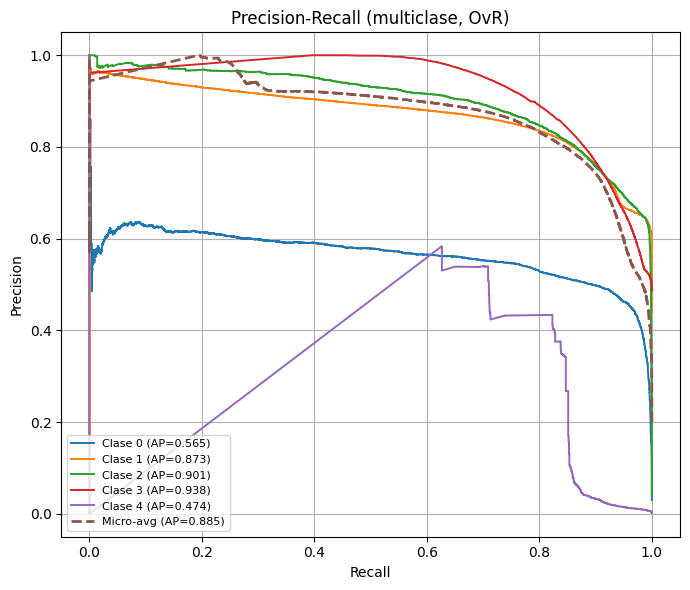

In [28]:
# Evaluación final del modelo tuneado en test
logits_te_best = mlp_best.predict(X_te, batch_size=model_params["batch_size"], verbose=0)
proba_best = tf.nn.softmax(logits_te_best).numpy()

_ = eval_predictions(y_true=y_te, y_pred=proba_best, plot_cm=True, plot_roc=True, plot_pr=True)



=== Resumen de modelos ===


,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,MLP_baseline,0.825488,0.626213,0.864884,0.686301,0.840881,0.825488,0.830048
1,MLP_tuned,0.818325,0.611114,0.868392,0.673668,0.842842,0.818325,0.823383


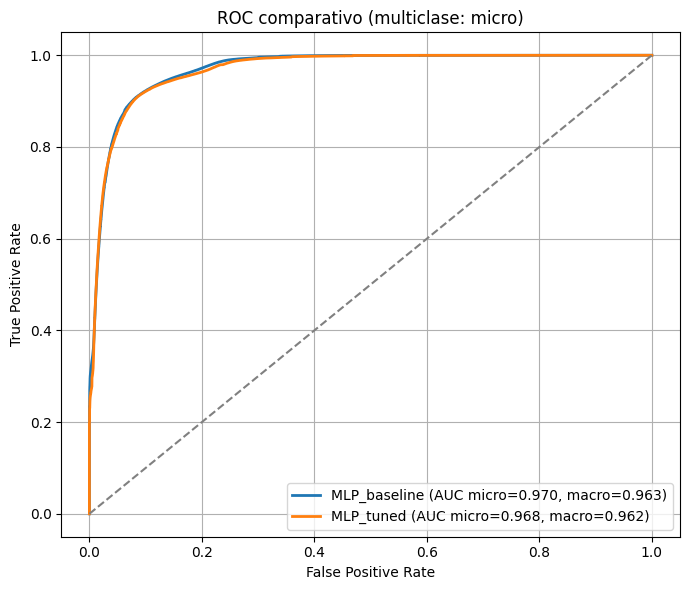

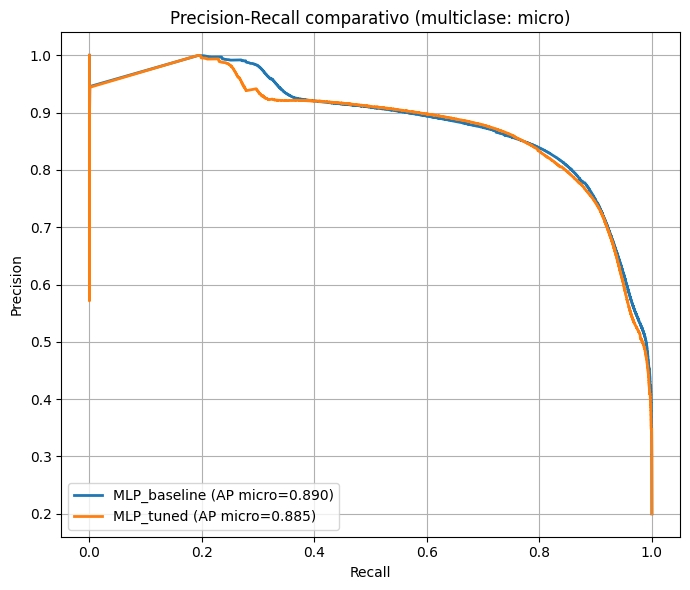

,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,MLP_baseline,0.825488,0.626213,0.864884,0.686301,0.840881,0.825488,0.830048
1,MLP_tuned,0.818325,0.611114,0.868392,0.673668,0.842842,0.818325,0.823383


In [29]:
res = compare_models(
    y_true=y_te,
    proba_dict={
        "MLP_baseline": proba_mlp,
        "MLP_tuned":    proba_best,
    },
    class_labels=np.unique(y_te),
    plot_roc=True,
    plot_pr=True,
)
res["summary"]


## Guardar el mejor modelo

Comparamos baseline vs tuned por **F1 macro** (más robusto a desbalance que accuracy) y guardamos el ganador como `models/mlp_signal_best.keras` junto con un JSON de metadata para que `inference.ipynb` reconstruya el pre-procesamiento de la señal.

In [ ]:
import json
import os
from sklearn.metrics import precision_recall_fscore_support

os.makedirs("models", exist_ok=True)

# Decidir el mejor por F1 macro
y_pred_baseline = proba_mlp.argmax(axis=1)
y_pred_tuned    = proba_best.argmax(axis=1)
_, _, f1_base,  _ = precision_recall_fscore_support(y_te, y_pred_baseline, average="macro", zero_division=0)
_, _, f1_tuned, _ = precision_recall_fscore_support(y_te, y_pred_tuned,    average="macro", zero_division=0)
print(f"F1 macro -> baseline: {f1_base:.4f} | tuned: {f1_tuned:.4f}")

if f1_base >= f1_tuned:
    best_model = mlp_tf
    best_name  = "baseline"
    best_hp_used = {
        "hidden_size1": model_params["hidden_size1"],
        "hidden_size2": model_params["hidden_size2"],
        "dropout": 0.0,
        "lr": model_params["lr"],
    }
    f1_best = f1_base
else:
    best_model = mlp_best
    best_name  = "tuned"
    best_hp_used = dict(best_hp.values)
    f1_best = f1_tuned

print(f"Ganador: {best_name} (F1 macro = {f1_best:.4f})")

# Guardar modelo (formato .keras nativo, ideal para hls4ml downstream)
best_path = "models/mlp_signal_best.keras"
best_model.save(best_path)
print(f"Modelo guardado en: {best_path}")

# Guardar también el "perdedor" para registro histórico
loser_model = mlp_best if best_name == "baseline" else mlp_tf
loser_path  = f"models/mlp_signal_{'tuned' if best_name == 'baseline' else 'baseline'}.keras"
loser_model.save(loser_path)
print(f"Modelo alternativo guardado en: {loser_path}")


In [ ]:
# Metadata: todo lo que inference.ipynb necesita para reproducir el pre-procesamiento
meta = {
    "model_path": best_path,
    "selected_variant": best_name,
    "f1_macro_test": float(f1_best),
    "num_classes": int(num_classes),
    "class_labels": [int(c) for c in np.unique(labels)],
    "preprocessing": {
        "signal_len": int(SIGNAL_LEN),
        "n_before":   int(N_BEFORE),
        "n_after":    int(N_AFTER),
        "scale":      SCALE,
        "normalize":  True,
    },
    "hyperparameters": best_hp_used,
    "class_weight": class_weight_dict,
    "trained_on": {
        "n_train": int(len(X_tr)),
        "n_val":   int(len(X_val)),
        "n_test":  int(len(X_te)),
    },
}

meta_path = "models/mlp_signal_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Metadata guardada en: {meta_path}")
print(json.dumps(meta, indent=2))
